In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

-Esta es una base de datos de salarios de personas que trabajan en industria de Software en diversos países. 
-La base de datos cuenta con la sgte información: año, experiencia, tipo de empleo, título, salario, moneda, salario en USD, residencia, remote_ratio, país de la compañía, tamaño de la compañía.
-La finalidad del proyecto es identificar valores relevantes desde distintas perspectivas. 

In [2]:
df = pd.read_csv('salaries.csv')

In [3]:
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M
...,...,...,...,...,...,...,...,...,...,...,...
151440,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
151441,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
151442,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
151443,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [5]:
df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


In [11]:
# Option 1: If using an older version of pandas, remove the parameter
df.describe()

# Option 2: If you need to focus on numeric columns only in an older pandas version
df.select_dtypes(include=['number']).describe()

# Option 3: Update pandas to a newer version (in a new cell)
# !pip install --upgrade pandas
# Then you can use: df.describe(numeric_only=True)

,work_year,salary,salary_in_usd,remote_ratio
count,151445.000000,1.514450e+05,151445.000000,151445.000000
mean,2024.435313,1.628380e+05,157527.458411,20.938625
std,0.671842,2.080124e+05,74150.772377,40.620393
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,105800.000000,0.000000
50%,2025.000000,1.470000e+05,146100.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [12]:
df['experience_level'].unique()

array(['EX', 'SE', 'MI', 'EN'], dtype=object)

In [13]:
df['work_year'].unique()

array([2025, 2024, 2023, 2022, 2020, 2021])

In [14]:
len(df['job_title'].unique())

422

In [15]:
df['job_title'].unique()

array(['Head of Data', 'Data Scientist', 'Engineer', 'AI Product Lead',
       'AI Engineer', 'Business Intelligence Engineer', 'Manager',
       'Computer Vision Engineer', 'Data Management', 'Product Manager',
       'Data Engineer', 'Machine Learning Engineer', 'Software Engineer',
       'Data Analyst', 'Research Scientist', 'Developer', 'Associate',
       'Computational Scientist', 'Analyst', 'AI Scientist',
       'DataOps Engineer', 'Prompt Engineer', 'Data Governance Engineer',
       'Analytics Engineer', 'AI Governance Specialist',
       'Backend Engineer', 'DevOps Engineer', 'Systems Engineer',
       'Tech Lead', 'Solutions Engineer', 'Product Analyst', 'Researcher',
       'Executive', 'Director', 'Consultant', 'Solutions Architect',
       'Data Reporting Specialist', 'BI Developer', 'Data Manager',
       'Machine Learning Scientist', 'Data Governance',
       'Applied Scientist', 'Data Architect', 'Statistical Programmer',
       'Data Specialist', 'Technical Architec

In [20]:
df['salary_currency'].unique()

array(['USD', 'EUR', 'GBP', 'CAD', 'INR', 'AUD', 'PLN', 'CHF', 'SGD',
       'CZK', 'NOK', 'MXN', 'PHP', 'JPY', 'HUF', 'TWD', 'BRL', 'ZAR',
       'DKK', 'ILS', 'TRY', 'SEK', 'NZD', 'HKD', 'THB', 'CLP'],
      dtype=object)

In [21]:
df['salary_currency'].value_counts()

salary_currency
USD    143173
GBP      4040
EUR      3053
CAD       667
INR       151
PLN       104
CHF        54
AUD        36
PHP        31
SGD        25
BRL        23
TWD        17
JPY        14
CZK        12
HUF         9
NOK         7
MXN         6
ZAR         5
DKK         5
TRY         4
ILS         3
THB         2
SEK         1
NZD         1
HKD         1
CLP         1
Name: count, dtype: int64

In [16]:
df.nunique()

work_year                 6
experience_level          4
employment_type           4
job_title               422
salary                12308
salary_currency          26
salary_in_usd         13580
employee_residence      104
remote_ratio              3
company_location         97
company_size              3
dtype: int64

In [17]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

Text(0.5, 1.0, 'Frecuencia de salarios')

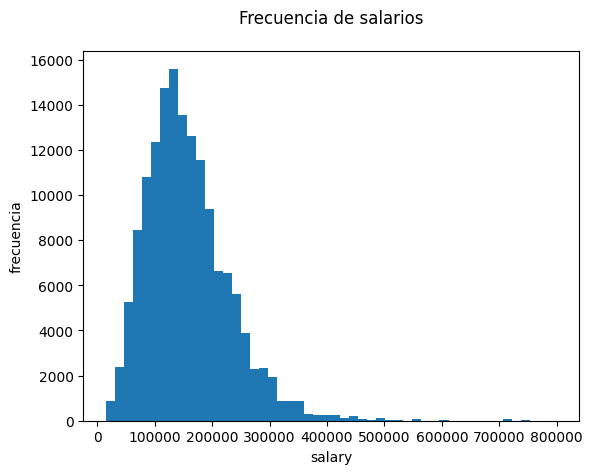

In [65]:
df["salary_in_usd"].hist(bins=50)
plt.grid()
plt.xlabel('salary')
plt.ylabel('frecuencia')
plt.title('Frecuencia de salarios', pad=20)

In [57]:
expert_stats=df.groupby("experience_level")["salary_in_usd"].agg(["count","mean","median","min","max"]).sort_values("mean", ascending=False)

total = expert_stats["count"].sum()

expert_stats["pct"] = (expert_stats["count"] / total * 100).round(2)


In [58]:
expert_stats

,count,mean,median,min,max,pct
experience_level,,,,,,
EX,4163,200471.428537,189370.0,15000,625000,2.75
SE,87491,172657.764364,161000.0,15645,800000,57.77
MI,46128,142301.177831,130000.0,15000,800000,30.46
EN,13663,98961.735270,86600.0,15000,793136,9.02


In [32]:
job_stats=(df.groupby("job_title")["salary_in_usd"]
               .agg(["count","mean","median"])
               .query("count >= 30")        # filtrar roles raros
               .sort_values("mean", ascending=False))

In [33]:
job_stats

,count,mean,median
job_title,,,
Engineering Manager,902,258211.426829,240000.0
Enterprise Account Executive,72,256135.722222,215189.5
Head of AI,62,249559.725806,239000.0
Director of Machine Learning,38,246492.105263,210000.0
Head of Data,336,221691.416667,210000.0
...,...,...,...
Research Associate,260,78183.200000,64732.5
Power BI,40,75762.350000,65631.5
Encounter Data Management Professional,50,75556.000000,74100.0


In [39]:
res_stats = (df.groupby("employee_residence")["salary_in_usd"]
               .agg(["count","mean","median"])
               .sort_values("count", ascending=False))

In [40]:
res_stats

,count,mean,median
employee_residence,,,
US,135506,163944.997934,151270.0
CA,6207,129644.120670,120000.0
GB,4172,95072.473873,75522.5
AU,590,128507.652542,117618.5
NL,482,78366.275934,72000.0
...,...,...,...
IQ,1,100000.000000,100000.0
CN,1,125404.000000,125404.0
BM,1,100000.000000,100000.0


In [38]:
df["employee_residence"].unique()

array(['US', 'CA', 'NL', 'FR', 'GB', 'DE', 'ES', 'IE', 'AU', 'LT', 'IN',
       'EE', 'SK', 'CZ', 'UA', 'FI', 'CO', 'AR', 'AT', 'EG', 'SG', 'MX',
       'IT', 'PL', 'BE', 'CH', 'GR', 'NZ', 'HR', 'PR', 'PT', 'BR', 'PH',
       'RO', 'ML', 'NO', 'CL', 'MY', 'SV', 'DO', 'GT', 'CR', 'LV', 'ZA',
       'JO', 'CY', 'TH', 'JM', 'JP', 'MT', 'MK', 'SI', 'HK', 'LS', 'ID',
       'PE', 'HU', 'PA', 'LU', 'DZ', 'KE', 'CD', 'SE', 'KR', 'TW', 'TR',
       'NG', 'DK', 'AE', 'BG', 'RS', 'EC', 'XK', 'ZM', 'AM', 'RW', 'IL',
       'LB', 'PK', 'HN', 'VE', 'BM', 'VN', 'GE', 'SA', 'OM', 'BA', 'UG',
       'MU', 'QA', 'RU', 'TN', 'GH', 'AD', 'MD', 'UZ', 'CF', 'KW', 'IR',
       'AS', 'CN', 'BO', 'IQ', 'JE'], dtype=object)

In [43]:
df["remote_ratio"].unique()

array([  0, 100,  50])

In [45]:
remote_stats = (
    df.groupby("remote_ratio")["salary_in_usd"]
      .agg(["count", "mean", "median"])
)

total = remote_stats["count"].sum()

remote_stats["pct"] = (remote_stats["count"] / total * 100).round(2)

mapping = {0: "In-office", 50: "Hybrid", 100: "Remote"}
remote_stats = remote_stats.rename(index=mapping)

remote_stats

,count,mean,median,pct
remote_ratio,,,,
In-office,119570,159382.780154,147000.0,78.95
Hybrid,329,81711.629179,69999.0,0.22
Remote,31546,151285.861599,145000.0,20.83


In [50]:
size_stats = (df.groupby("company_size")["salary_in_usd"]
                .agg(["count","mean","median"])
                .sort_values("mean", ascending=False))

total = size_stats["count"].sum()

size_stats["pct"] = (size_stats["count"] / total * 100).round(2)

In [51]:
size_stats

,count,mean,median,pct
company_size,,,,
L,3926,159339.729496,149800.0,2.59
M,147302,157581.824483,146400.0,97.26
S,217,87835.258065,75000.0,0.14


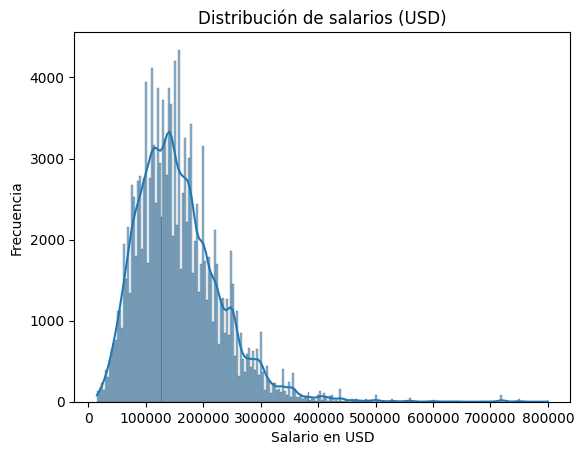

In [60]:
# Distribución de Salarios
sns.histplot(df["salary_in_usd"], kde=True)
plt.title("Distribución de salarios (USD)")
plt.xlabel("Salario en USD")
plt.ylabel("Frecuencia")
plt.show()

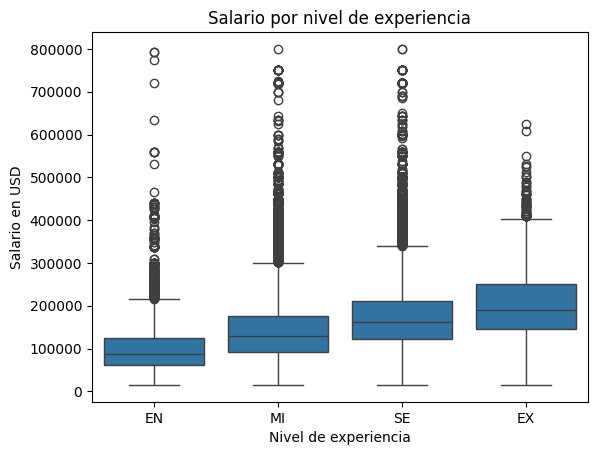

In [67]:
# Salario vs. nivel de experiencia
sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd",
    order=["EN", "MI", "SE", "EX"]  # si existen estos niveles
)
plt.title("Salario por nivel de experiencia")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Salario en USD")
plt.show()

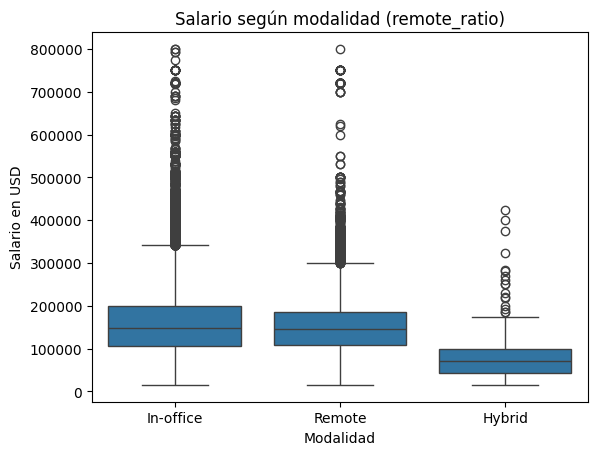

In [71]:
# Salario y modalidad remota
mapping = {0: "In-office", 50: "Hybrid", 100: "Remote"}
df["remote_type"] = df["remote_ratio"].map(mapping)

sns.boxplot(data=df, x="remote_type", y="salary_in_usd")
plt.title("Salario según modalidad (remote_ratio)")
plt.xlabel("Modalidad")
plt.ylabel("Salario en USD")
plt.show()


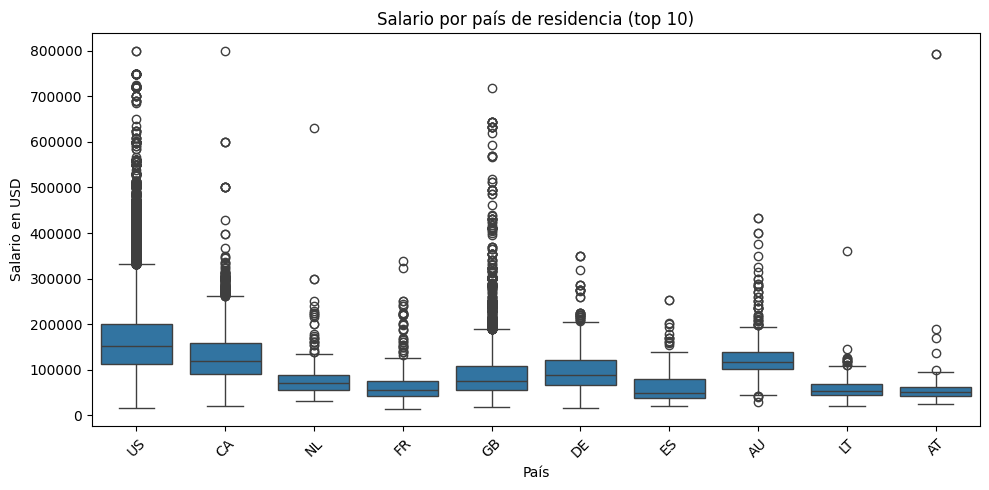

In [72]:
# Salario por país de residencia
top_countries = df["employee_residence"].value_counts().head(10).index
df_top = df[df["employee_residence"].isin(top_countries)]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_top,
    x="employee_residence",
    y="salary_in_usd"
)
plt.title("Salario por país de residencia (top 10)")
plt.xlabel("País")
plt.ylabel("Salario en USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

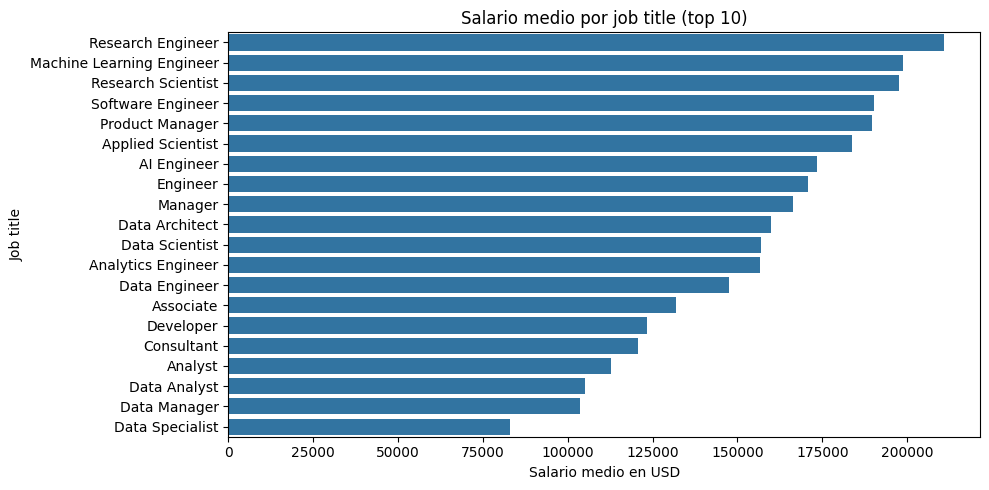

In [74]:
# Salario por Job title
top_titles = df["job_title"].value_counts().head(20).index
df_titles = df[df["job_title"].isin(top_titles)]

mean_by_title = (
    df_titles.groupby("job_title")["salary_in_usd"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=mean_by_title.values, y=mean_by_title.index)
plt.title("Salario medio por job title (top 10)")
plt.xlabel("Salario medio en USD")
plt.ylabel("Job title")
plt.tight_layout()
plt.show()

In [75]:
# Podría conocer el mínimo y máximo de cada Job Title. Por ejemplo Research Engineer
mask = df["job_title"].str.lower() == "research engineer"
df_re = df[mask]

df_re["salary_in_usd"].min(), df_re["salary_in_usd"].max()


(np.int64(16455), np.int64(750000))

In [77]:
mask = df["job_title"].str.lower() == "machine learning engineer"
df_re = df[mask]

df_re["salary_in_usd"].min(), df_re["salary_in_usd"].max()

(np.int64(15966), np.int64(750000))

In [ ]:
# Mover los cálculos en Looker Studio